In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'

data_path = project_path + '/data/raw/archive/data/data'
train_path = data_path + '/train'
test_path = data_path + '/test'

print("SERIAL 11 loaded successfully.")

SERIAL 11 loaded successfully.


In [3]:
from google.colab import drive

drive.mount('/content/drive')

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'

data_path = project_path + '/data/raw/archive/data/data'
train_path = data_path + '/train'
test_path = data_path + '/test'

print("Drive mounted successfully.")
print("Train folder exists:", os.path.exists(train_path))
print("Test folder exists:", os.path.exists(test_path))

Mounted at /content/drive
Drive mounted successfully.
Train folder exists: True
Test folder exists: True


In [4]:
summary_data = []

for file in os.listdir(train_path):
    if file.endswith(".npy"):
        channel = file.replace(".npy", "")
        data = np.load(os.path.join(train_path, file))
        telemetry = data[:, 0]

        summary_data.append({
            "Channel": channel,
            "Std": np.std(telemetry)
        })

summary_df = pd.DataFrame(summary_data)

# Keep channels with meaningful variation
usable_channels = summary_df[summary_df["Std"] >= 0.01]["Channel"].tolist()

print("Usable channels:", len(usable_channels))
print("First 10 channels:", usable_channels[:10])

Usable channels: 58
First 10 channels: ['E-13', 'T-9', 'E-11', 'E-3', 'E-7', 'P-7', 'D-15', 'G-3', 'F-7', 'E-10']


In [5]:
train_telemetry = {}
test_telemetry = {}

for channel in usable_channels:
    train_file = os.path.join(train_path, channel + ".npy")
    test_file = os.path.join(test_path, channel + ".npy")

    train_data = np.load(train_file)
    test_data = np.load(test_file)

    # First column = telemetry signal
    train_telemetry[channel] = train_data[:, 0]
    test_telemetry[channel] = test_data[:, 0]

print("Training channels loaded:", len(train_telemetry))
print("Testing channels loaded:", len(test_telemetry))

print("E-13 training shape:", train_telemetry["E-13"].shape)
print("E-13 testing shape:", test_telemetry["E-13"].shape)

Training channels loaded: 58
Testing channels loaded: 58
E-13 training shape: (2880,)
E-13 testing shape: (8640,)


In [6]:
# Calculate the difference between consecutive telemetry values

train_diff = {}
test_diff = {}

for channel in usable_channels:
    train_signal = train_telemetry[channel]
    test_signal = test_telemetry[channel]

    train_diff[channel] = np.diff(train_signal)
    test_diff[channel] = np.diff(test_signal)

print("E-13 original shape:", train_telemetry["E-13"].shape)
print("E-13 difference shape:", train_diff["E-13"].shape)

print("First 10 E-13 differences:")
print(train_diff["E-13"][:10])

E-13 original shape: (2880,)
E-13 difference shape: (2879,)
First 10 E-13 differences:
[-0.00641029  0.06027047  0.00996655 -0.00397035 -0.03459738 -0.03811445
 -0.02828633 -1.38386641 -0.16372333  0.01448447]


In [7]:
diff_E13 = train_diff["E-13"]

print("Mean difference:", np.mean(diff_E13))
print("Standard deviation:", np.std(diff_E13))
print("Minimum difference:", np.min(diff_E13))
print("Maximum difference:", np.max(diff_E13))

Mean difference: -0.0004949663725588393
Standard deviation: 0.22504864129694668
Minimum difference: -1.6488099970180634
Maximum difference: 1.705743899318213


#rolling mean

In [8]:
window = 10

train_rolling_mean = {}
test_rolling_mean = {}

for channel in usable_channels:
    train_signal = train_telemetry[channel]
    test_signal = test_telemetry[channel]

    train_rolling_mean[channel] = (
        pd.Series(train_signal)
        .rolling(window=window)
        .mean()
        .to_numpy()
    )

    test_rolling_mean[channel] = (
        pd.Series(test_signal)
        .rolling(window=window)
        .mean()
        .to_numpy()
    )

print("E-13 rolling mean shape:", train_rolling_mean["E-13"].shape)
print("First 15 values:")
print(train_rolling_mean["E-13"][:15])

E-13 rolling mean shape: (2880,)
First 15 values:
[        nan         nan         nan         nan         nan         nan
         nan         nan         nan  0.53859785  0.38117315  0.22582221
  0.06444423 -0.09651326 -0.2570737 ]


#rolling standard deviation

In [9]:
train_rolling_std = {}
test_rolling_std = {}

for channel in usable_channels:
    train_signal = train_telemetry[channel]
    test_signal = test_telemetry[channel]

    train_rolling_std[channel] = (
        pd.Series(train_signal)
        .rolling(window=window)
        .std()
        .to_numpy()
    )

    test_rolling_std[channel] = (
        pd.Series(test_signal)
        .rolling(window=window)
        .std()
        .to_numpy()
    )

print("E-13 rolling std shape:", train_rolling_std["E-13"].shape)

print("First 15 values:")
print(train_rolling_std["E-13"][:15])

E-13 rolling std shape: (2880,)
First 15 values:
[       nan        nan        nan        nan        nan        nan
        nan        nan        nan 0.64492451 0.75053579 0.80832138
 0.82423198 0.80206089 0.74208037]


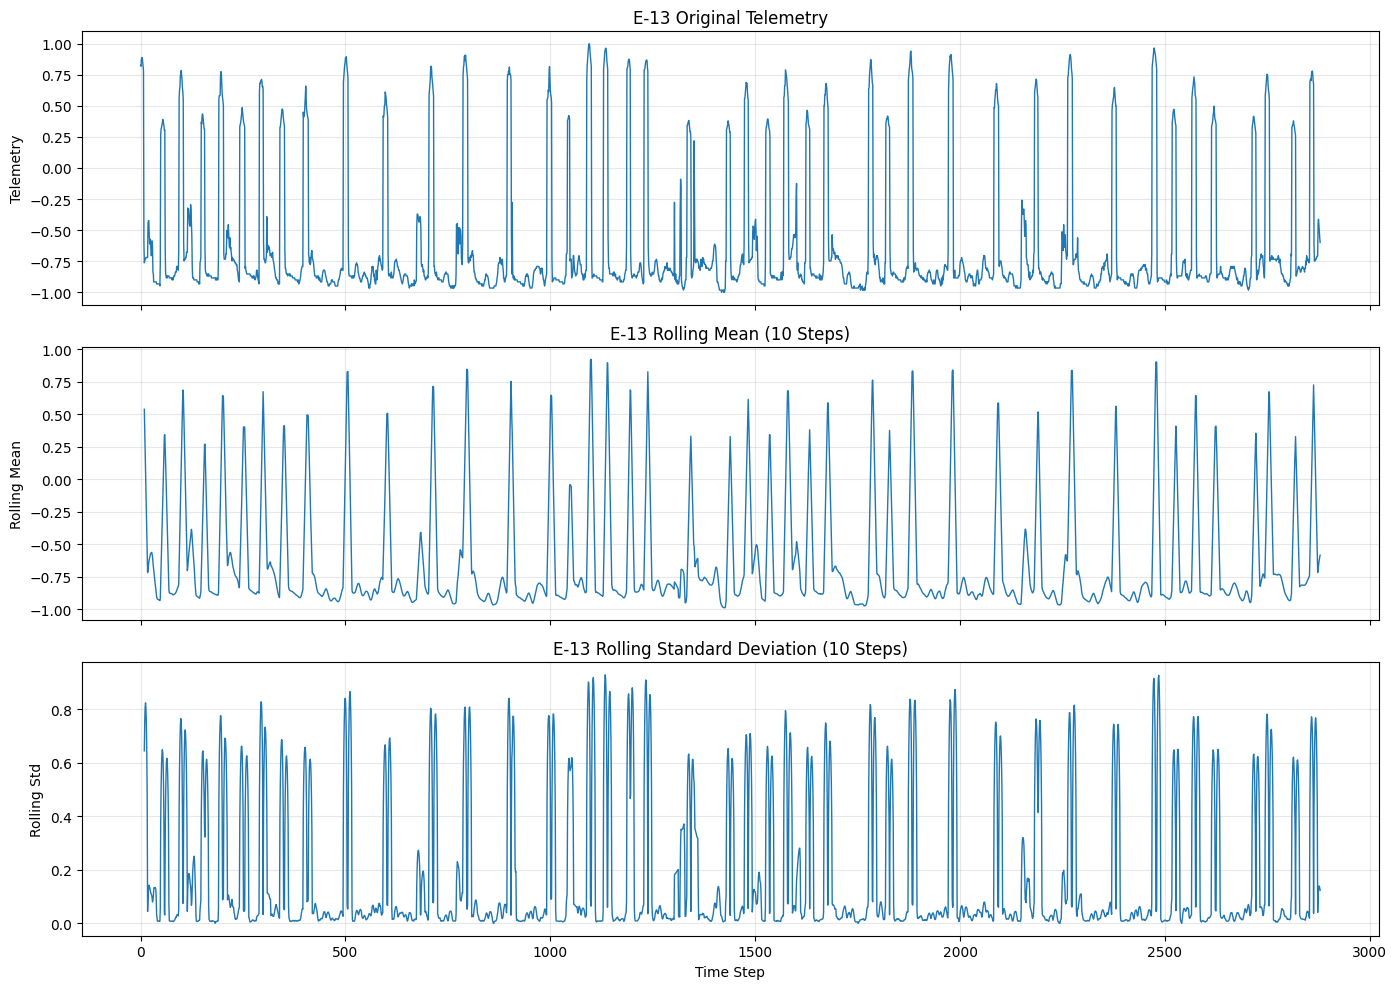

In [10]:
channel = "E-13"

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Original telemetry
axes[0].plot(train_telemetry[channel], linewidth=1)
axes[0].set_title("E-13 Original Telemetry")
axes[0].set_ylabel("Telemetry")
axes[0].grid(True, alpha=0.3)

# Rolling mean
axes[1].plot(train_rolling_mean[channel], linewidth=1)
axes[1].set_title("E-13 Rolling Mean (10 Steps)")
axes[1].set_ylabel("Rolling Mean")
axes[1].grid(True, alpha=0.3)

# Rolling standard deviation
axes[2].plot(train_rolling_std[channel], linewidth=1)
axes[2].set_title("E-13 Rolling Standard Deviation (10 Steps)")
axes[2].set_xlabel("Time Step")
axes[2].set_ylabel("Rolling Std")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Absolute difference = |current − previous|

In [11]:
train_abs_diff = {}
test_abs_diff = {}

for channel in usable_channels:
    train_abs_diff[channel] = np.abs(train_diff[channel])
    test_abs_diff[channel] = np.abs(test_diff[channel])

print("E-13 absolute difference shape:", train_abs_diff["E-13"].shape)

print("First 10 absolute differences:")
print(train_abs_diff["E-13"][:10])

E-13 absolute difference shape: (2879,)
First 10 absolute differences:
[0.00641029 0.06027047 0.00996655 0.00397035 0.03459738 0.03811445
 0.02828633 1.38386641 0.16372333 0.01448447]


In [12]:
abs_diff_E13 = train_abs_diff["E-13"]

print("Mean absolute difference:", np.mean(abs_diff_E13))
print("Standard deviation:", np.std(abs_diff_E13))
print("Minimum absolute difference:", np.min(abs_diff_E13))
print("Maximum absolute difference:", np.max(abs_diff_E13))

Mean absolute difference: 0.06127987166003229
Standard deviation: 0.21654540694884689
Minimum absolute difference: 0.0
Maximum absolute difference: 1.705743899318213


In [13]:
channel = "E-13"

feature_df_E13 = pd.DataFrame({
    "telemetry": train_telemetry[channel],
    "difference": np.concatenate([[np.nan], train_diff[channel]]),
    "absolute_difference": np.concatenate([[np.nan], train_abs_diff[channel]]),
    "rolling_mean": train_rolling_mean[channel],
    "rolling_std": train_rolling_std[channel]
})

print("Feature table shape:", feature_df_E13.shape)
print("\nFirst 15 rows:")
print(feature_df_E13.head(15))

Feature table shape: (2880, 5)

First 15 rows:
    telemetry  difference  absolute_difference  rolling_mean  rolling_std
0    0.825732         NaN                  NaN           NaN          NaN
1    0.819322   -0.006410             0.006410           NaN          NaN
2    0.879593    0.060270             0.060270           NaN          NaN
3    0.889559    0.009967             0.009967           NaN          NaN
4    0.885589   -0.003970             0.003970           NaN          NaN
5    0.850991   -0.034597             0.034597           NaN          NaN
6    0.812877   -0.038114             0.038114           NaN          NaN
7    0.784591   -0.028286             0.028286           NaN          NaN
8   -0.599276   -1.383866             1.383866           NaN          NaN
9   -0.762999   -0.163723             0.163723      0.538598     0.644925
10  -0.748515    0.014484             0.014484      0.381173     0.750536
11  -0.734187    0.014327             0.014327      0.225822     

In [14]:
feature_df_E13_clean = feature_df_E13.dropna().reset_index(drop=True)

print("Original feature table:", feature_df_E13.shape)
print("After removing incomplete rows:", feature_df_E13_clean.shape)

print("\nRemaining missing values:")
print(feature_df_E13_clean.isna().sum())

Original feature table: (2880, 5)
After removing incomplete rows: (2871, 5)

Remaining missing values:
telemetry              0
difference             0
absolute_difference    0
rolling_mean           0
rolling_std            0
dtype: int64


In [15]:
print(feature_df_E13_clean.describe())

         telemetry    difference  absolute_difference  rolling_mean  \
count  2871.000000  2.871000e+03          2871.000000   2871.000000   
mean     -0.605668 -4.640431e-19             0.060905     -0.603958   
std       0.541349  2.239111e-01             0.215466      0.443621   
min      -1.000000 -1.648810e+00             0.000000     -0.988102   
25%      -0.900641 -1.578765e-02             0.000000     -0.886246   
50%      -0.853277  0.000000e+00             0.015620     -0.816516   
75%      -0.720016  1.545400e-02             0.030743     -0.508125   
max       1.000000  1.705744e+00             1.705744      0.923098   

       rolling_std  
count  2871.000000  
mean      0.196071  
std       0.267168  
min       0.000000  
25%       0.017835  
50%       0.043609  
75%       0.384495  
max       0.929033  


#Create features for all 58 channels

In [16]:
train_features = {}
test_features = {}

for channel in usable_channels:

    # Original telemetry
    train_signal = train_telemetry[channel]
    test_signal = test_telemetry[channel]

    # Difference
    train_difference = np.diff(train_signal)
    test_difference = np.diff(test_signal)

    # Absolute difference
    train_absolute_difference = np.abs(train_difference)
    test_absolute_difference = np.abs(test_difference)

    # Rolling statistics
    train_rolling_mean_signal = (
        pd.Series(train_signal)
        .rolling(window=10)
        .mean()
        .to_numpy()
    )

    test_rolling_mean_signal = (
        pd.Series(test_signal)
        .rolling(window=10)
        .mean()
        .to_numpy()
    )

    train_rolling_std_signal = (
        pd.Series(train_signal)
        .rolling(window=10)
        .std()
        .to_numpy()
    )

    test_rolling_std_signal = (
        pd.Series(test_signal)
        .rolling(window=10)
        .std()
        .to_numpy()
    )

    # Create aligned feature tables
    train_df = pd.DataFrame({
        "telemetry": train_signal,
        "difference": np.concatenate([[np.nan], train_difference]),
        "absolute_difference": np.concatenate(
            [[np.nan], train_absolute_difference]
        ),
        "rolling_mean": train_rolling_mean_signal,
        "rolling_std": train_rolling_std_signal
    })

    test_df = pd.DataFrame({
        "telemetry": test_signal,
        "difference": np.concatenate([[np.nan], test_difference]),
        "absolute_difference": np.concatenate(
            [[np.nan], test_absolute_difference]
        ),
        "rolling_mean": test_rolling_mean_signal,
        "rolling_std": test_rolling_std_signal
    })

    # Remove incomplete initial rows
    train_features[channel] = train_df.dropna().reset_index(drop=True)
    test_features[channel] = test_df.dropna().reset_index(drop=True)

print("Training feature tables:", len(train_features))
print("Testing feature tables:", len(test_features))

print("E-13 training feature shape:", train_features["E-13"].shape)
print("E-13 testing feature shape:", test_features["E-13"].shape)

Training feature tables: 58
Testing feature tables: 58
E-13 training feature shape: (2871, 5)
E-13 testing feature shape: (8631, 5)


#Verify all channels are clean

In [17]:
nan_channels = []
inf_channels = []

for channel in usable_channels:

    train_df = train_features[channel]
    test_df = test_features[channel]

    if train_df.isna().any().any() or test_df.isna().any().any():
        nan_channels.append(channel)

    if np.isinf(train_df.to_numpy()).any() or np.isinf(test_df.to_numpy()).any():
        inf_channels.append(channel)

print("Channels with NaN values:", len(nan_channels))
print("Channels with infinite values:", len(inf_channels))

print("NaN channels:", nan_channels)
print("Infinite-value channels:", inf_channels)

Channels with NaN values: 0
Channels with infinite values: 0
NaN channels: []
Infinite-value channels: []


#summary of the engineered features

In [18]:
feature_summary = []

for channel in usable_channels:
    train_df = train_features[channel]

    feature_summary.append({
        "Channel": channel,
        "Time Steps": len(train_df),
        "Features": len(train_df.columns),
        "Telemetry Mean": train_df["telemetry"].mean(),
        "Telemetry Std": train_df["telemetry"].std(),
        "Mean Absolute Difference": train_df["absolute_difference"].mean(),
        "Mean Rolling Std": train_df["rolling_std"].mean()
    })

feature_summary_df = pd.DataFrame(feature_summary)

print("Feature summary shape:", feature_summary_df.shape)
print("\nFirst 10 channels:")
print(feature_summary_df.head(10))

Feature summary shape: (58, 7)

First 10 channels:
  Channel  Time Steps  Features  Telemetry Mean  Telemetry Std  \
0    E-13        2871         5       -0.605668       0.541349   
1     T-9         430         5        0.286826       0.176022   
2    E-11        2871         5       -0.586017       0.809819   
3     E-3        2871         5        0.134800       0.417223   
4     E-7        2760         5       -0.970047       0.043475   
5     P-7        2844         5        0.004440       0.240598   
6    D-15        2065         5        0.781457       0.652238   
7     G-3        2615         5        0.987763       0.155993   
8     F-7        2502         5       -0.607671       0.611493   
9    E-10        2871         5       -0.586231       0.809399   

   Mean Absolute Difference  Mean Rolling Std  
0                  0.060905          0.196071  
1                  0.032558          0.047282  
2                  0.058516          0.231580  
3                  0.015255   

#Save the feature summary

In [19]:
feature_summary_path = project_path + '/results/feature_engineering_summary.csv'

feature_summary_df.to_csv(feature_summary_path, index=False)

print("Feature summary saved successfully.")
print("Path:", feature_summary_path)
print("File exists:", os.path.exists(feature_summary_path))

Feature summary saved successfully.
Path: /content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/feature_engineering_summary.csv
File exists: True


#Final SERIAL 11 verification

In [20]:
print("===== SERIAL 11 FINAL VERIFICATION =====")

print("Usable channels:", len(usable_channels))
print("Training feature tables:", len(train_features))
print("Testing feature tables:", len(test_features))

print("\nFeature columns:")
print(list(train_features["E-13"].columns))

print("\nE-13 training shape:", train_features["E-13"].shape)
print("E-13 testing shape:", test_features["E-13"].shape)

print("\nTotal NaN values:",
      sum(df.isna().sum().sum() for df in train_features.values()))

print("Total infinite values:",
      sum(np.isinf(df.to_numpy()).sum() for df in train_features.values()))

print("\nSummary file exists:",
      os.path.exists(feature_summary_path))

===== SERIAL 11 FINAL VERIFICATION =====
Usable channels: 58
Training feature tables: 58
Testing feature tables: 58

Feature columns:
['telemetry', 'difference', 'absolute_difference', 'rolling_mean', 'rolling_std']

E-13 training shape: (2871, 5)
E-13 testing shape: (8631, 5)

Total NaN values: 0
Total infinite values: 0

Summary file exists: True


#COMMIT github

In [21]:
%cd /content/drive/MyDrive/Spacecraft-Anomaly-Detection

!git add notebooks/11_feature_engineering.ipynb
!git add results/feature_engineering_summary.csv

!git commit -m "Complete SERIAL 11 feature engineering"

/content/drive/MyDrive/Spacecraft-Anomaly-Detection
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@9a795b55a5b7.(none)')


In [22]:
!git config --global user.name "Amit Chandra Das"
!git config --global user.email "arickroy0@gmail.com"

In [ ]:
%cd /content/drive/MyDrive/Spacecraft-Anomaly-Detection

!git status
!git log -1 --oneline

/content/drive/MyDrive/Spacecraft-Anomaly-Detection
